In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, spearmanr
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import eli5
from eli5.sklearn import PermutationImportance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler



In [71]:
df = pd.read_csv('http://theta.edu.pl/wp-content/uploads/2025/10/Gut_KEGG_paths_sample_2.csv',sep=';')
df.head()

,pond,pond_5,pond_3,pond_2,water_supp,feed_supp,EMfarma,EM,ko04910,ko04142,...,ko05020,ko00660,ko00450,ko00280,ko00626,ko00630,ko00740,ko00980,ko05322,ko00195
0,S8.4.Gut,0,0,0,0,0,0,0,1.398362,0.856962,...,-3.305118,2.701175,3.211082,3.279931,2.176028,3.314016,2.420496,1.919627,-8.057328,2.804603
1,S8.5.Gut,0,0,0,0,0,0,0,1.529817,0.678607,...,-5.190662,2.739143,3.188719,3.101493,2.029106,3.175526,2.233949,1.710292,-8.090434,3.033549
2,S8.2.Gut,0,0,0,0,0,0,0,1.473606,1.036224,...,-3.778859,2.778266,3.306274,3.354010,2.278097,3.357028,2.491940,2.037277,-8.144121,2.874695
3,S8.3.Gut,0,0,0,0,0,0,0,1.558820,0.927564,...,-4.704125,2.804935,3.296110,3.262444,2.196549,3.285973,2.410094,1.907508,-8.264034,3.012302
4,S9.80.Gut,3,1,0,2,0,0,1,1.254914,1.090120,...,-1.956041,2.705257,3.253699,3.313818,2.315874,3.389404,2.552479,2.143053,-5.827566,2.646252


In [72]:

print(df.shape)
print(df.info())
df.describe().T.head(20)

(124, 163)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Columns: 163 entries, pond to ko00195
dtypes: float64(155), int64(7), object(1)
memory usage: 158.0+ KB
None


,count,mean,std,min,25%,50%,75%,max
pond_5,124.0,2.016129,1.414121,0.000000,1.000000,2.000000,3.000000,4.000000
pond_3,124.0,1.209677,0.746528,0.000000,1.000000,1.000000,2.000000,2.000000
pond_2,124.0,0.403226,0.492535,0.000000,0.000000,0.000000,1.000000,1.000000
water_supp,124.0,1.209677,0.746528,0.000000,1.000000,1.000000,2.000000,2.000000
feed_supp,124.0,0.403226,0.492535,0.000000,0.000000,0.000000,1.000000,1.000000
EMfarma,124.0,0.403226,0.492535,0.000000,0.000000,0.000000,1.000000,1.000000
EM,124.0,0.604839,0.490869,0.000000,0.000000,1.000000,1.000000,1.000000
ko04910,124.0,1.325796,0.225061,0.721434,1.163491,1.329111,1.452207,2.195042
ko04142,124.0,0.720128,0.541357,-2.937678,0.472891,0.763319,1.081071,1.386400
ko04144,124.0,-7.783299,0.674684,-8.976718,-8.097476,-7.923687,-7.703540,-5.421380


In [219]:
df.isna().mean()

pond          0.0
pond_5        0.0
pond_3        0.0
pond_2        0.0
water_supp    0.0
             ... 
ko00630       0.0
ko00740       0.0
ko00980       0.0
ko05322       0.0
ko00195       0.0
Length: 163, dtype: float64

In [74]:
meta_cols = ['pond', 'pond_5', 'pond_3', 'pond_2', 'water_supp', 
             'feed_supp', 'EMfarma', 'EM']
ko_cols = [k for k in df.columns if k.startswith('ko')]

meta = df[meta_cols]
X = df[ko_cols]

X.head()

,ko04910,ko04142,ko04144,ko00590,ko00830,ko04930,ko03450,ko00100,ko00190,ko00330,...,ko05020,ko00660,ko00450,ko00280,ko00626,ko00630,ko00740,ko00980,ko05322,ko00195
0,1.398362,0.856962,-8.057328,1.499377,0.389335,1.263555,-8.057328,-8.057328,4.325137,4.136587,...,-3.305118,2.701175,3.211082,3.279931,2.176028,3.314016,2.420496,1.919627,-8.057328,2.804603
1,1.529817,0.678607,-8.090434,1.463094,0.177785,1.227160,-8.090434,-5.787849,4.223123,4.138060,...,-5.190662,2.739143,3.188719,3.101493,2.029106,3.175526,2.233949,1.710292,-8.090434,3.033549
2,1.473606,1.036224,-8.144121,1.618586,0.502828,1.334120,-8.144121,-8.144121,4.423235,4.223744,...,-3.778859,2.778266,3.306274,3.354010,2.278097,3.357028,2.491940,2.037277,-8.144121,2.874695
3,1.558820,0.927564,-8.264034,1.603686,0.366009,1.310948,-8.264034,-6.877740,4.362582,4.215064,...,-4.704125,2.804935,3.296110,3.262444,2.196549,3.285973,2.410094,1.907508,-8.264034,3.012302
4,1.254914,1.090120,-8.024790,1.547987,0.834164,1.242981,-5.080351,-5.827566,4.375433,4.127713,...,-1.956041,2.705257,3.253699,3.313818,2.315874,3.389404,2.552479,2.143053,-5.827566,2.646252


In [75]:
for col in meta_cols:
    print(col)
    print(meta[col].value_counts())
    print('---')

pond
pond
S8.4.Gut      1
S8.5.Gut      1
S8.2.Gut      1
S8.3.Gut      1
S9.80.Gut     1
             ..
S32.71.Gut    1
S32.73.Gut    1
S32.72.Gut    1
S32.75.Gut    1
S32.74.Gut    1
Name: count, Length: 124, dtype: int64
---
pond_5
pond_5
3    25
4    25
2    25
1    25
0    24
Name: count, dtype: int64
---
pond_3
pond_3
1    50
2    50
0    24
Name: count, dtype: int64
---
pond_2
pond_2
0    74
1    50
Name: count, dtype: int64
---
water_supp
water_supp
2    50
1    50
0    24
Name: count, dtype: int64
---
feed_supp
feed_supp
0    74
1    50
Name: count, dtype: int64
---
EMfarma
EMfarma
0    74
1    50
Name: count, dtype: int64
---
EM
EM
1    75
0    49
Name: count, dtype: int64
---


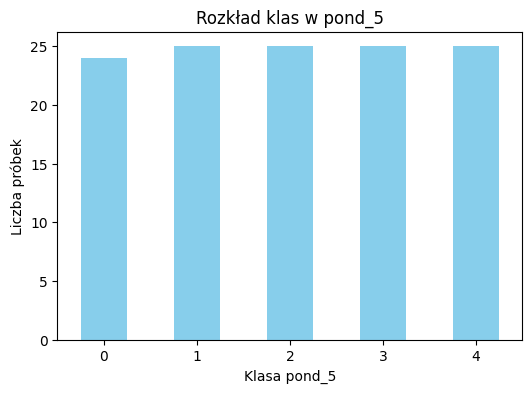

In [76]:

import pandas as pd
import matplotlib.pyplot as plt

class_counts = meta['pond_5'].value_counts().sort_index()

plt.figure(figsize=(6,4))
class_counts.plot(kind='bar', color='skyblue')
plt.xlabel('Klasa pond_5')
plt.ylabel('Liczba próbek')
plt.title('Rozkład klas w pond_5')
plt.xticks(rotation=0)
plt.show()

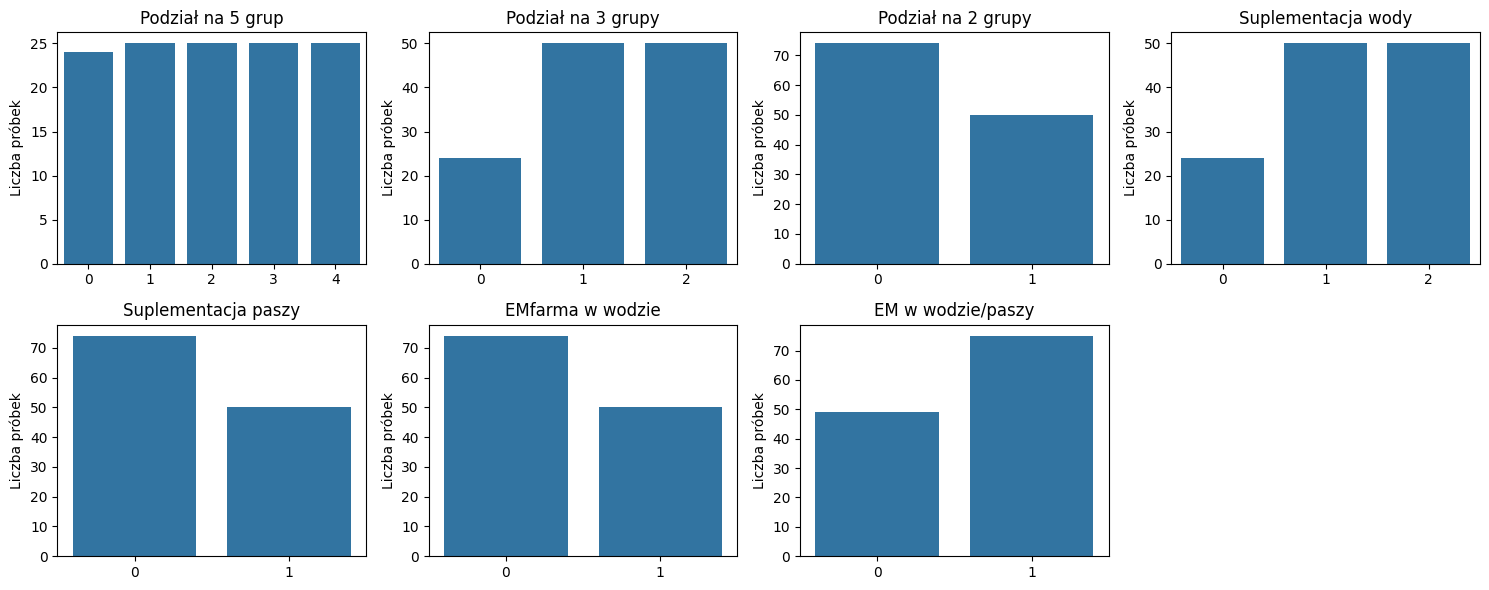

In [77]:
metadata_cols = ['pond_5', 'pond_3', 'pond_2', 'water_supp', 'feed_supp', 'EMfarma', 'EM']


metadata_labels = {
    'pond_5': 'Podział na 5 grup',
    'pond_3': 'Podział na 3 grupy',
    'pond_2': 'Podział na 2 grupy',
    'water_supp': 'Suplementacja wody',
    'feed_supp': 'Suplementacja paszy',
    'EMfarma': 'EMfarma w wodzie',
    'EM': 'EM w wodzie/paszy'
}

n_cols = len(metadata_cols)
n_rows = 2
n_cols_plot = (n_cols + 1) // 2

fig, axes = plt.subplots(n_rows, n_cols_plot, figsize=(15,6))
axes = axes.flatten()

for i, col in enumerate(metadata_cols):
    sns.countplot(x=col, data=meta, ax=axes[i])
    axes[i].set_title(metadata_labels[col])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Liczba próbek')
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

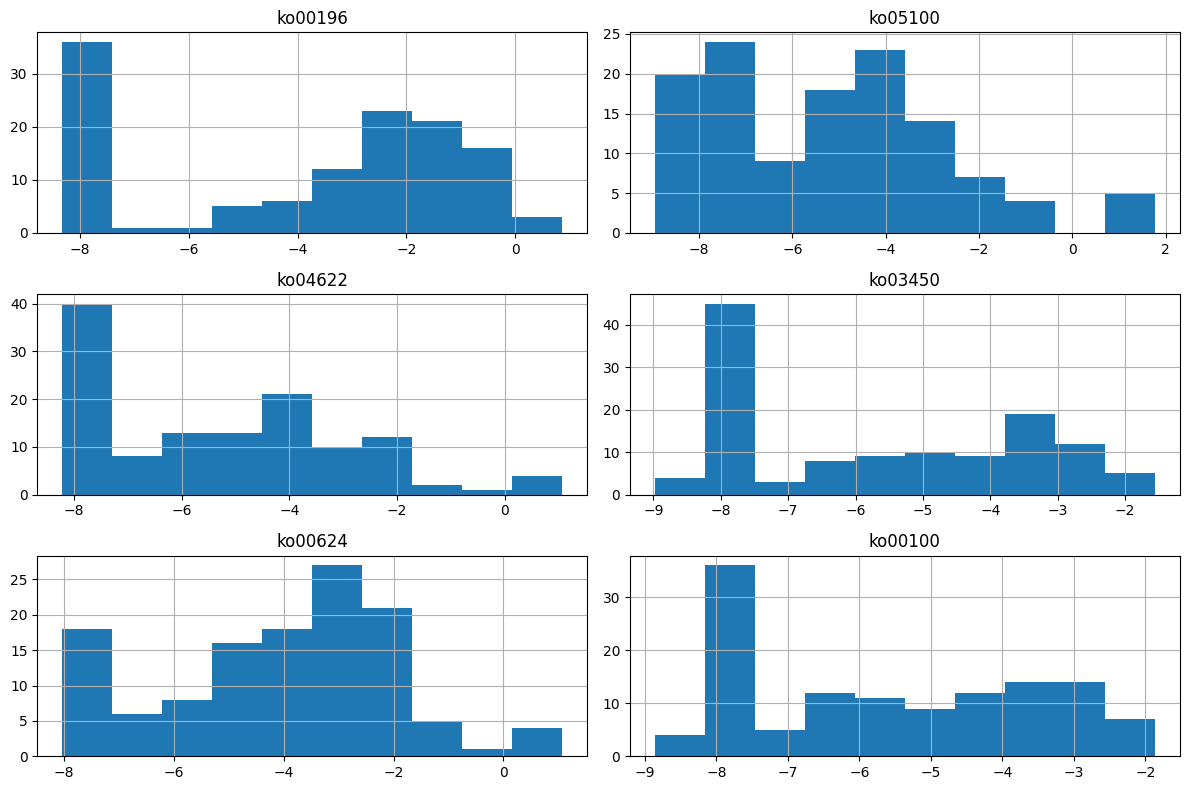

Najbardziej zmienne KO: ['ko00196', 'ko05100', 'ko04622', 'ko03450', 'ko00624', 'ko00100']


In [78]:
stds = X.std().sort_values(ascending=False)
top_cols = stds.head(6).index

X[top_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

print("Najbardziej zmienne KO:", list(top_cols))

In [79]:
from scipy.stats import shapiro


normalne_count = 0
nienormalne_count = 0

for col in X.columns:
    data = X[col].dropna()
    stat, p = shapiro(data)

    if p > 0.05:
        normalne_count += 1
    else:
        nienormalne_count += 1

print("Wyniki testów normalności")
print(f"Normalne:     {normalne_count}")
print(f"Nienormalne:  {nienormalne_count}")



Wyniki testów normalności
Normalne:     42
Nienormalne:  113



Normalność rozkładu oceniono przy użyciu testu Shapiro–Wilka. Wyniki pokazują, że zdecydowana większość cech (113 z 155) nie ma rozkładu normalnego. W związku zastosowana została nieparametryczna metoda korelacji Spearmana, która nie wymaga normalności danych i jest odporna na wartości odstające.

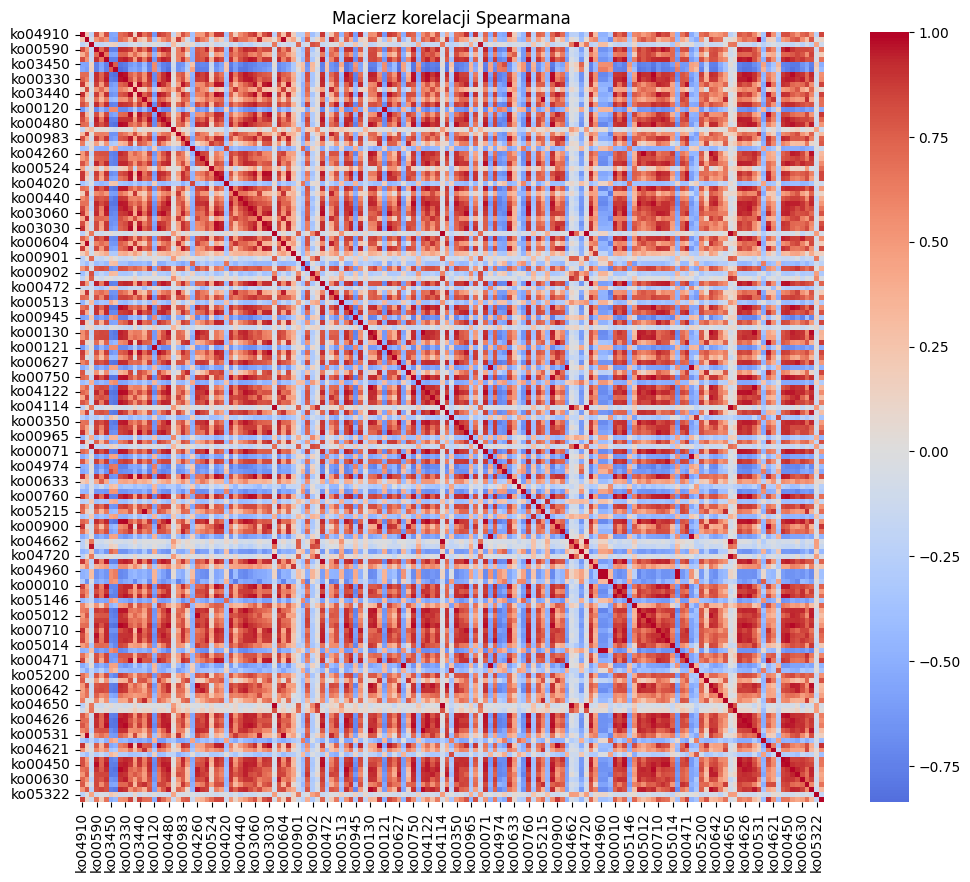

In [80]:
ko_cols = X.columns

corr_with_target = X[ko_cols].corrwith(df['pond_5'], method='spearman')
corr_with_target = corr_with_target.sort_values(ascending=False)

corr_matrix = df[ko_cols].corr(method='spearman')

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Macierz korelacji Spearmana")
plt.show()

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, df['pond_5'], test_size=0.2, stratify=df['pond_5'], random_state=42)

In [82]:
from scipy.stats import spearmanr
ko_cols_train = X_train.columns
to_drop = []

for i in range(len(ko_cols_train)):
    for j in range(i+1, len(ko_cols_train)):
        ko1 = ko_cols_train[i]
        ko2 = ko_cols_train[j]
        r, p = spearmanr(X_train[ko1], X_train[ko2])

        if abs(r) > 0.8:
            if X_train[ko1].var() > X_train[ko2].var():
                if ko2 not in to_drop:
                    to_drop.append(ko2)
            else:
                if ko1 not in to_drop:
                    to_drop.append(ko1)

to_drop = list(set(to_drop))
X_train = X_train.drop(columns=to_drop, axis=1)

print("po redukcji:", X_train.shape[1])

po redukcji: 35


In [83]:
X_test = X_test.drop(columns=to_drop, axis=1)

In [84]:
print(X_train.shape)
print(X_test.shape)

(99, 35)
(25, 35)


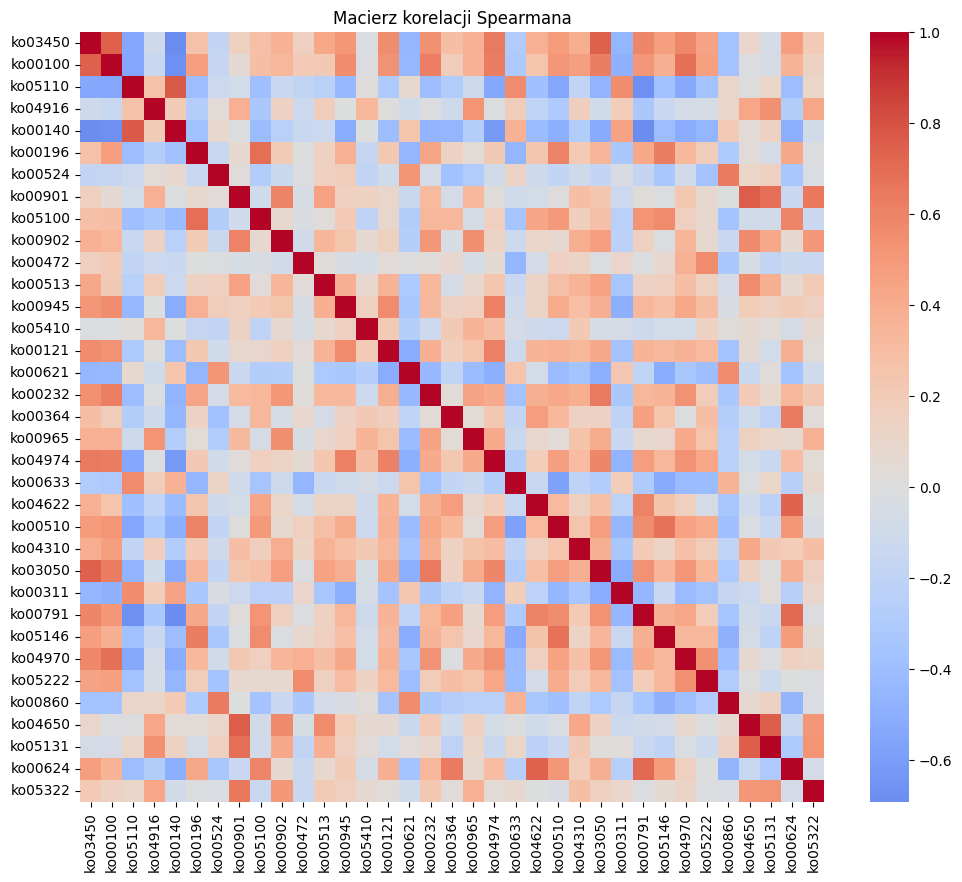

In [85]:
corr_matrix_reduced = X_train.corr(method='spearman')
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix_reduced, cmap='coolwarm', center=0)
plt.title("Macierz korelacji Spearmana")
plt.show()

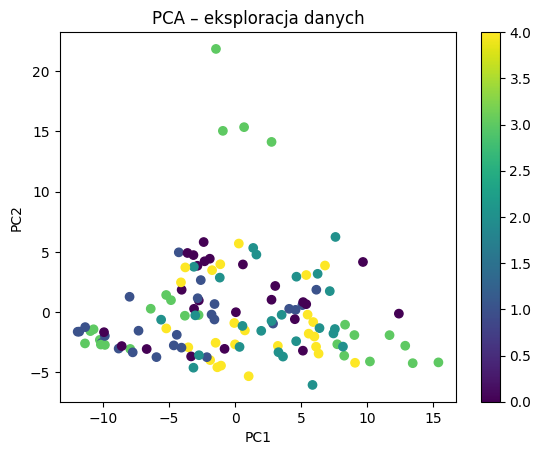

In [86]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:,0], X_pca[:,1], c=df['pond_5'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA – eksploracja danych")
plt.colorbar()
plt.show()

Brak separowalności liniowej w przestrzeni głównych składowych.

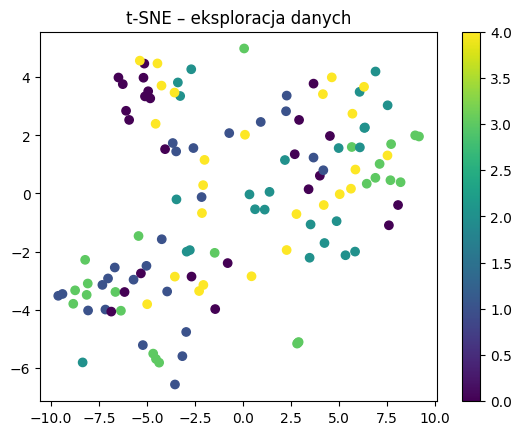

In [87]:
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X)

plt.scatter(X_tsne[:,0], X_tsne[:,1], c=df['pond_5'])
plt.title("t-SNE – eksploracja danych")
plt.colorbar()
plt.show()

Wykorzystano Principal Component Analysis (PCA) do zredukowania wymiarów do dwóch komponentów (PC1 i PC2) i wizualizacji próbek.

Punkty są dość rozrzucone, co pokazuje dużą zmienność danych.

Klasy pond_5 częściowo się mieszają, brak wyraźnych oddzielonych grup.

Pojedyncze punkty odstające mogą wskazywać na nietypowe próbki (outliery).

PCA pozwala ocenić strukturę danych i informacyjność cech KO przed zastosowaniem klasyfikatora.

Ogólne wnioski z eksploracji

Dane mają dużą zmienność, szczególnie w wybranych KO, co jest korzystne dla klasyfikacji.

Niektóre cechy są stabilne i mogą wnosić mniej informacji, dlatego przydatna będzie redukcja wymiarów.

Klasy pond_5 są prawie równomierne, ale częściowe nakładanie się punktów sugeruje, że klasyfikacja może wymagać bardziej zaawansowanych metod.

Obecność punktów odstających warto uwzględnić w dalszej analizie.

In [88]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, df['pond_5'], stratify=df['pond_5'], random_state=42)

In [89]:
X_train2.shape

(93, 155)

In [90]:
X_train.shape

(99, 35)

Dane po redukjcji korelacją: X_train, y_train, y_test, X_test
Dane do PCA: X_train2, X_test2, y_train2, y_test2

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("--- Testowanie Logistycznej Regresji (Baseline)")


log_reg = LogisticRegression(  
    l1_ratio=1,            
    C=0.2,                 
    max_iter=5000,        
    solver='saga',        
    random_state=42,
)

log_reg.fit(X_train, y_train)


y_pred_logreg = log_reg.predict(X_test)
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)


print(f"Test Accuracy (LogReg, L1, BEZ SCALERA): {accuracy_logreg:.4f}")
print(f'Treningowe accuracy: {log_reg.score(X_train, y_train)}')

--- Testowanie Logistycznej Regresji (Baseline)
Test Accuracy (LogReg, L1, BEZ SCALERA): 0.4800
Treningowe accuracy: 0.6767676767676768


In [92]:
print(classification_report(y_pred_logreg, y_test))

              precision    recall  f1-score   support

           0       0.20      0.25      0.22         4
           1       0.80      0.50      0.62         8
           2       0.60      0.43      0.50         7
           3       0.40      0.67      0.50         3
           4       0.40      0.67      0.50         3

    accuracy                           0.48        25
   macro avg       0.48      0.50      0.47        25
weighted avg       0.55      0.48      0.49        25



In [93]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("--- Testowanie Logistycznej Regresji na danych po PCA")


log_reg2 = LogisticRegression(  
    l1_ratio=1,            
    C=0.2,                 
    max_iter=5000,        
    solver='saga',        
    random_state=42,
)

pca_log_reg_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95)),
    ('log_reg', log_reg2)
])

pca_log_reg_pipeline.fit(X_train2, y_train2)

y_pred_logreg_pca = pca_log_reg_pipeline.predict(X_test2)
accuracy_logreg = accuracy_score(y_test2, y_pred_logreg_pca)


print(f"Test Accuracy: {accuracy_logreg:.4f}")
print(f'Treningowe accuracy: {pca_log_reg_pipeline.score(X_train2, y_train2)}')
print(classification_report(y_test2, y_pred_logreg_pca))

--- Testowanie Logistycznej Regresji na danych po PCA
Test Accuracy: 0.4516
Treningowe accuracy: 0.6559139784946236
              precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.50      0.67      0.57         6
           2       0.44      0.67      0.53         6
           3       0.25      0.14      0.18         7
           4       0.40      0.33      0.36         6

    accuracy                           0.45        31
   macro avg       0.44      0.46      0.44        31
weighted avg       0.43      0.45      0.43        31



In [94]:
#dla danych X_train i y_train
svc_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42))
])

svc_pipeline.fit(X_train, y_train)
y_pred_svc = svc_pipeline.predict(X_test)
accuracy_svc = accuracy_score(y_test, y_pred_svc)

print(f"Test Accuracy: {accuracy_svc:.4f}")
print(f'Treningowe accuracy: {svc_pipeline.score(X_train, y_train)}')
print(classification_report(y_test, y_pred_svc))

Test Accuracy: 0.5200
Treningowe accuracy: 0.898989898989899
              precision    recall  f1-score   support

           0       0.67      0.40      0.50         5
           1       0.50      0.60      0.55         5
           2       0.43      0.60      0.50         5
           3       0.50      0.60      0.55         5
           4       0.67      0.40      0.50         5

    accuracy                           0.52        25
   macro avg       0.55      0.52      0.52        25
weighted avg       0.55      0.52      0.52        25



In [95]:
svc_pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('svc', SVC(C=4.0, kernel='rbf', gamma='scale', random_state=42))
])

svc_pipeline_pca.fit(X_train2, y_train2)
y_pred_svc_pca = svc_pipeline_pca.predict(X_test2)
accuracy_svc = accuracy_score(y_test2, y_pred_svc_pca)

print(f"Test Accuracy: {accuracy_svc:.4f}")
print(f'Treningowe accuracy: {svc_pipeline_pca.score(X_train2, y_train2)}')
print(classification_report(y_test2, y_pred_svc_pca))

Test Accuracy: 0.6129
Treningowe accuracy: 0.9139784946236559
              precision    recall  f1-score   support

           0       1.00      0.67      0.80         6
           1       0.40      0.33      0.36         6
           2       0.57      0.67      0.62         6
           3       0.60      0.86      0.71         7
           4       0.60      0.50      0.55         6

    accuracy                           0.61        31
   macro avg       0.63      0.60      0.61        31
weighted avg       0.63      0.61      0.61        31



In [96]:
rf_corr = RandomForestClassifier(max_depth=1, min_samples_leaf=5,n_estimators=1000, random_state=42)
rf_corr.fit(X_train, y_train)

y_pred_rf = rf_corr.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Test Accuracy: {accuracy_rf:.4f}")
print(f'Treningowe accuracy: {rf_corr.score(X_train, y_train)}')
print(classification_report(y_test, y_pred_rf))

Test Accuracy: 0.5600
Treningowe accuracy: 0.696969696969697
              precision    recall  f1-score   support

           0       0.33      0.20      0.25         5
           1       0.56      1.00      0.71         5
           2       0.57      0.80      0.67         5
           3       1.00      0.40      0.57         5
           4       0.50      0.40      0.44         5

    accuracy                           0.56        25
   macro avg       0.59      0.56      0.53        25
weighted avg       0.59      0.56      0.53        25



In [97]:
rf_pca = RandomForestClassifier(max_depth=1, min_samples_leaf=15, n_estimators=2000, random_state=42)

rf_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=0.95)),
    ('rf_pca', rf_pca)
])

rf_pca_pipeline.fit(X_train2, y_train2)

y_pred_rf_pca = rf_pca_pipeline.predict(X_test2)
accuracy_rf_pca = accuracy_score(y_test2, y_pred_rf_pca)

print(f"Test Accuracy: {accuracy_rf_pca:.4f}")
print(f'Treningowe accuracy: {rf_pca_pipeline.score(X_train2, y_train2)}')
print(classification_report(y_test2, y_pred_rf_pca))

Test Accuracy: 0.4194
Treningowe accuracy: 0.7419354838709677
              precision    recall  f1-score   support

           0       1.00      0.17      0.29         6
           1       0.33      0.33      0.33         6
           2       0.33      0.67      0.44         6
           3       0.60      0.43      0.50         7
           4       0.43      0.50      0.46         6

    accuracy                           0.42        31
   macro avg       0.54      0.42      0.41        31
weighted avg       0.54      0.42      0.41        31



In [98]:
#dane po redukcji korelacjami
X_train_array = X_train.values
X_test_array = X_test.values
y_train_array = to_categorical(y_train)
y_test_array = to_categorical(y_test)

In [99]:
tf.random.set_seed(42)

In [100]:
#model dla danych po corr
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[35]),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [101]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
model.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])
history = model.fit(
    X_train_array,
    y_train_array,
    epochs=200,
    validation_data=(X_test_array, y_test_array)
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.1414 - loss: 3.5386 - val_accuracy: 0.1600 - val_loss: 2.3750
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2121 - loss: 2.0539 - val_accuracy: 0.2000 - val_loss: 2.2636
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1717 - loss: 2.0518 - val_accuracy: 0.2000 - val_loss: 2.0707
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.1717 - loss: 1.8889 - val_accuracy: 0.1600 - val_loss: 1.9166
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1919 - loss: 1.8028 - val_accuracy: 0.2000 - val_loss: 1.8626
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2121 - loss: 1.7353 - val_accuracy: 0.2000 - val_loss: 1.8176
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2121 - loss: 1.6623 - val_accuracy: 0.1600 - val_loss: 1.7696
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2626 - loss: 1.5963 - val_accuracy: 0.2800 - val_loss:

In [102]:
results = model.evaluate(
    X_test_array,
    y_test_array,
    verbose=0
)
loss= results[0]
accuracy = results[1]
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Test Loss: 1.5145
Test Accuracy: 0.5200


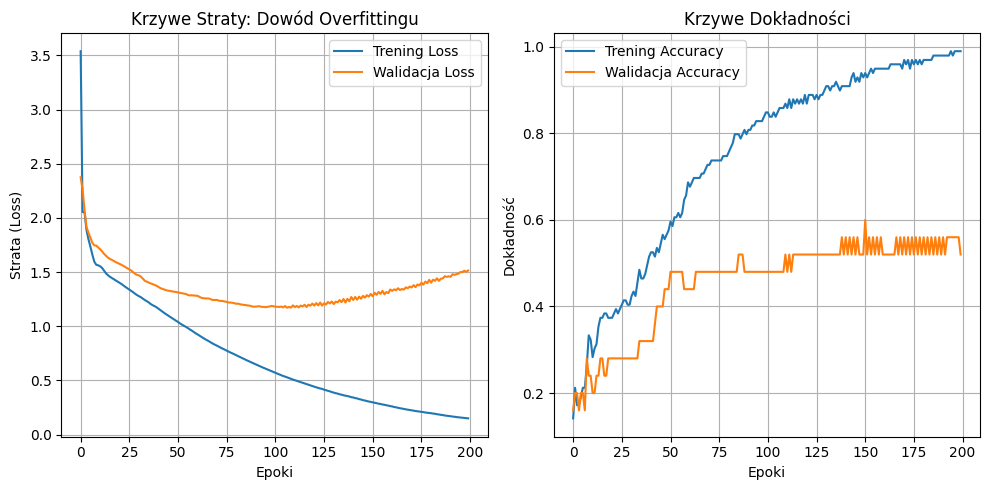

In [103]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Trening Loss')
plt.plot(history.history['val_loss'], label='Walidacja Loss')
plt.title('Krzywe Straty: Dowód Overfittingu')
plt.xlabel('Epoki')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Trening Accuracy')
plt.plot(history.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Krzywe Dokładności')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [104]:
tf.keras.backend.clear_session()

In [105]:
model2 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[35]),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.002)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.002)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=l2(0.002)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=l2(0.002)),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [106]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model2.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])


history = model2.fit(
    X_train_array,
    y_train_array,
    epochs=200,
    validation_data=(X_test_array, y_test_array),
)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.1818 - loss: 2.7046 - val_accuracy: 0.2400 - val_loss: 2.2248
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2121 - loss: 2.4924 - val_accuracy: 0.2000 - val_loss: 2.2108
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1717 - loss: 2.4035 - val_accuracy: 0.3200 - val_loss: 2.1930
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1717 - loss: 2.3007 - val_accuracy: 0.2000 - val_loss: 2.1792
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2323 - loss: 2.2786 - val_accuracy: 0.2400 - val_loss: 2.1629
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1818 - loss: 2.2850 - val_accuracy: 0.2400 - val_loss: 2.1560
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2323 - loss: 2.2562 - val_accuracy: 0.2800 - val_loss: 2.1650
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.2121 - loss: 2.2231 - val_accuracy: 0.2000 - val_loss:

In [107]:
results2 = model2.evaluate(
    X_test_array,
    y_test_array,
    verbose=0
)
loss = results2[0]
accuracy=results2[1]
print(f'Loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

Loss: 1.7176
Test accuracy: 0.5200


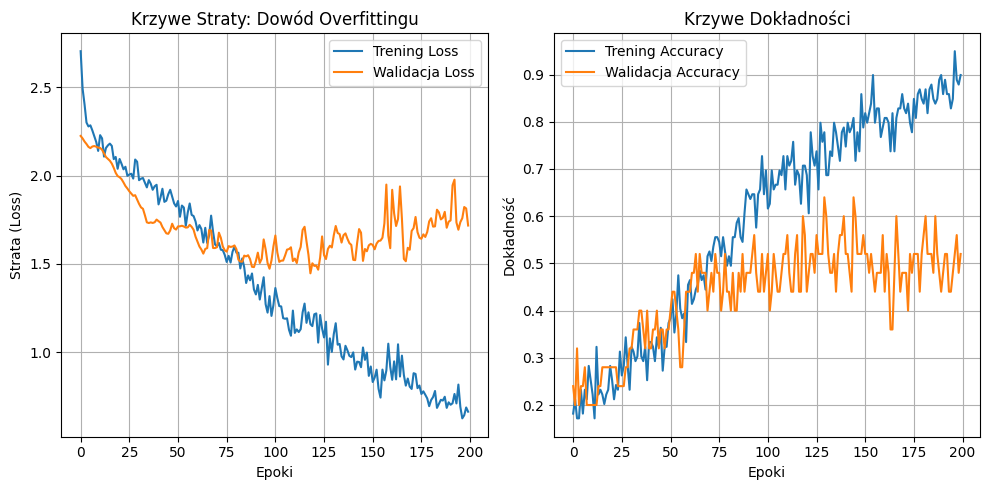

In [108]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Trening Loss')
plt.plot(history.history['val_loss'], label='Walidacja Loss')
plt.title('Krzywe Straty: Dowód Overfittingu')
plt.xlabel('Epoki')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Trening Accuracy')
plt.plot(history.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Krzywe Dokładności')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [109]:
tf.keras.backend.clear_session()

In [110]:
model3 = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[35]),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.003)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.003)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=l2(0.003)),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [111]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,413 (99.27 KB)

 Trainable params: 25,413 (99.27 KB)

 Non-trainable params: 0 (0.00 B)

In [112]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

model3.compile(loss='categorical_crossentropy', 
               optimizer=optimizer,
               metrics=['accuracy'])

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history3 = model3.fit(
    X_train_array, y_train_array,
    epochs=400,
    validation_data=(X_test_array, y_test_array),
    callbacks=[early_stopping_cb]
)

Epoch 1/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.2525 - loss: 4.5672 - val_accuracy: 0.2000 - val_loss: 2.5665
Epoch 2/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1818 - loss: 3.6429 - val_accuracy: 0.1600 - val_loss: 2.2461
Epoch 3/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2727 - loss: 2.7832 - val_accuracy: 0.1600 - val_loss: 2.1700
Epoch 4/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2323 - loss: 2.8206 - val_accuracy: 0.2800 - val_loss: 2.1715
Epoch 5/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1616 - loss: 2.8593 - val_accuracy: 0.2400 - val_loss: 2.1386
Epoch 6/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1515 - loss: 2.7896 - val_accuracy: 0.2400 - val_loss: 2.0982
Epoch 7/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1414 - loss: 2.8833 - val_accuracy: 0.2800 - val_loss: 2.0770
Epoch 8/400
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.2323 - loss: 2.4396 - val_accuracy: 0.3200 - val_loss:

In [113]:
results = model3.evaluate(
    X_test_array,
    y_test_array,
    verbose=0
)
print(f'Loss: {results[0]}')
print(f'Test Accuracy: {results[1]}')

Loss: 1.5298798084259033
Test Accuracy: 0.5600000023841858


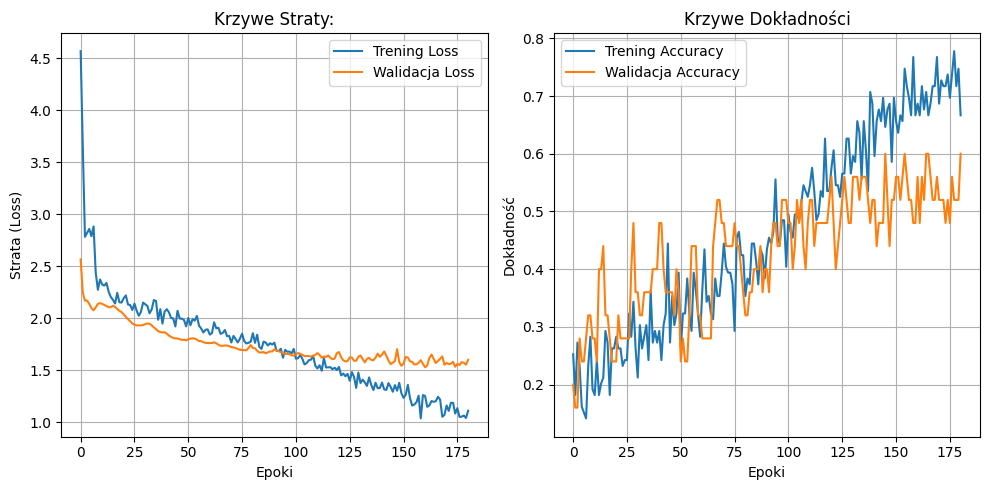

In [114]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history3.history['loss'], label='Trening Loss')
plt.plot(history3.history['val_loss'], label='Walidacja Loss')
plt.title('Krzywe Straty:')
plt.xlabel('Epoki')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history3.history['accuracy'], label='Trening Accuracy')
plt.plot(history3.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Krzywe Dokładności')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


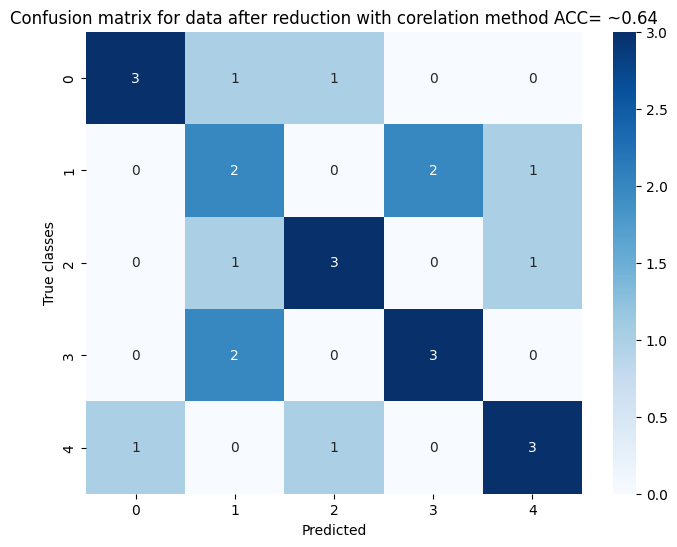

In [115]:
y_pred_probs = model3.predict(X_test_array)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_array, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3', '4'],
            yticklabels=['0', '1', '2', '3', '4'])
plt.xlabel('Predicted')
plt.ylabel('True classes')
plt.title('Confusion matrix for data after reduction with corelation method ACC= ~0.64')
plt.show()

In [215]:
def keras_predict_wrapper(X):
    return np.argmax(model3.predict(X, verbose=0), axis=1)

def score_accuracy_for_pfi(estimator, X, y_true):
    y_pred = keras_predict_wrapper(X)
    return accuracy_score(y_true, y_pred)

perm = PermutationImportance(
    estimator=model3,
    scoring=score_accuracy_for_pfi,
    random_state=42,
    cv='prefit',
    n_iter=10
)

perm.fit(X_test_array, y_true_classes)

feature_names = X_test.columns.tolist()

print("--- Ważność Cech (Permutation Feature Importance) ---")
eli5.show_weights(
    perm,
    feature_names=feature_names,
    top=20
)


--- Ważność Cech (Permutation Feature Importance) ---


Weight,Feature
0.1480 ± 0.0625,ko05100
0.1160 ± 0.0560,ko00624
0.0960 ± 0.0891,ko05222
0.0880 ± 0.0784,ko00791
0.0880 ± 0.0599,ko00196
0.0840 ± 0.1040,ko00472
0.0800 ± 0.0716,ko03450
0.0760 ± 0.0755,ko00945
0.0760 ± 0.0835,ko03050
0.0640 ± 0.0816,ko00140


In [216]:
mean_weight = [
    0.1480, 0.1160, 0.0960, 0.0880, 0.0880,
    0.0840, 0.0800, 0.0760, 0.0760, 0.0640,
    0.0480, 0.0440, 0.0360, 0.0240, 0.0240,
    0.0240, 0.0160, 0.0160, 0.0120, 0.0080
]

std_error = [
    0.0625, 0.0560, 0.0891, 0.0784, 0.0599,
    0.1040, 0.0716, 0.0755, 0.0835, 0.0816,
    0.0480, 0.0560, 0.0665, 0.0816, 0.0531,
    0.0392, 0.0392, 0.0531, 0.0367, 0.0480
]

ko = [
    "ko05100", "ko00624", "ko05222", "ko00791", "ko00196",
    "ko00472", "ko03450", "ko00945", "ko03050", "ko00140",
    "ko00100", "ko00311", "ko04622", "ko04310", "ko05110",
    "ko04970", "ko04916", "ko05131", "ko00901", "ko00364"
]
data = {
    'Feature': ko,
    'Mean_weight': mean_weight,
    'Std_error': std_error
}

df_pfi = pd.DataFrame(data)
df_pfi = df_pfi.sort_values(by='Mean_weight', ascending=True)

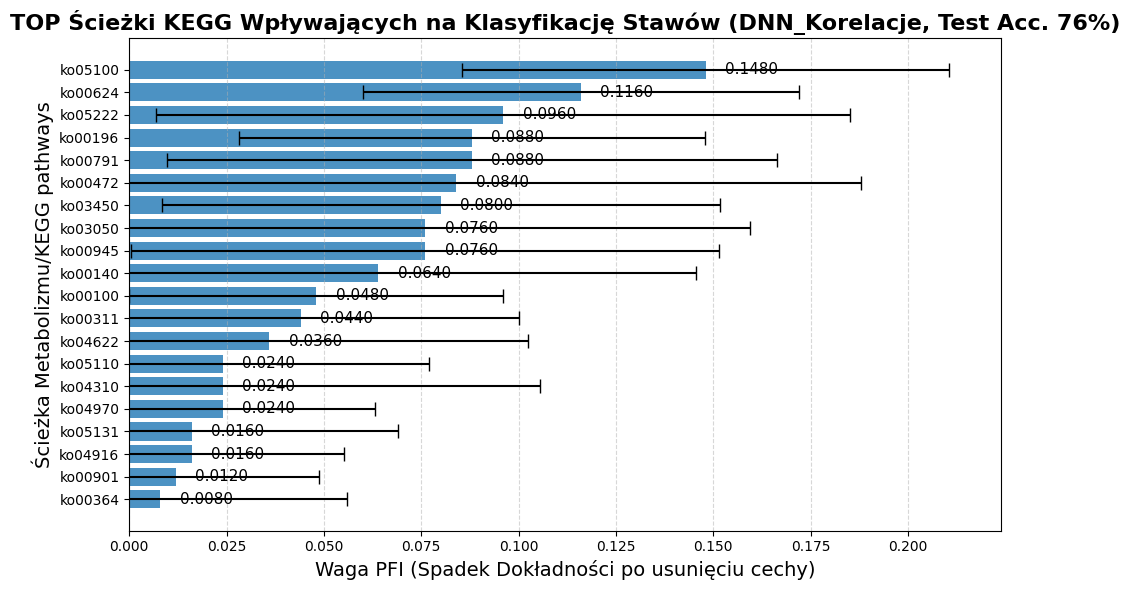

In [218]:

plt.figure(figsize=(10, 6))
bars = plt.barh(
    df_pfi['Feature'],
    df_pfi['Mean_weight'],
    xerr=df_pfi['Std_error'],
    color='#1f77b4',
    capsize=5,
    alpha=0.8
)

plt.title(
    'TOP Ścieżki KEGG Wpływających na Klasyfikację Stawów (DNN_Korelacje, Test Acc. 76%)',
    fontsize=16,
    weight='bold'
)
plt.xlabel('Waga PFI (Spadek Dokładności po usunięciu cechy)', fontsize=14)
plt.ylabel('Ścieżka Metabolizmu/KEGG pathways', fontsize=14)
plt.xlim(0)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height()/2,
        f"{width:.4f}",
        ha='left',
        va='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [116]:
y_pca = df['pond_5']
X_pca = df.drop(columns=meta_cols, axis=1)
X_pca.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Columns: 155 entries, ko04910 to ko00195
dtypes: float64(155)
memory usage: 150.3 KB


In [117]:
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y_pca, test_size=0.2, stratify=y_pca, random_state=42)

In [118]:
pca = PCA(n_components=0.95)
X_train_pca_transformed = pca.fit_transform(X_train_pca)
X_test_pca_transformed = pca.transform(X_test_pca)

In [119]:
X_train_pca_transformed.shape

(99, 20)

In [120]:
X_test_pca_transformed.shape

(25, 20)

In [121]:
y_train_pca_arr = to_categorical(y_train_pca)
y_test_pca_arr = to_categorical(y_test_pca)

In [204]:
tf.keras.backend.clear_session()

In [205]:
model3_copy_pca = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape=[20]),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=l2(0.005)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=l2(0.005)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=l2(0.005)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(5, activation='softmax')
])

In [166]:
model3_copy_pca.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,429 (29.02 KB)

 Trainable params: 7,429 (29.02 KB)

 Non-trainable params: 0 (0.00 B)

In [206]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model3_copy_pca.compile(loss='categorical_crossentropy',
                        optimizer=optimizer,
                        metrics=['accuracy'])

history_model_pca = model3_copy_pca.fit(
    X_train_pca_transformed, y_train_pca_arr,
    epochs=300,
    validation_data = (X_test_pca_transformed, y_test_pca_arr),
    callbacks = [early_stopping_cb]
)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.1919 - loss: 2.8370 - val_accuracy: 0.0800 - val_loss: 2.3030
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1616 - loss: 3.0644 - val_accuracy: 0.1200 - val_loss: 2.2455
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2828 - loss: 2.5563 - val_accuracy: 0.1200 - val_loss: 2.2037
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1919 - loss: 2.5329 - val_accuracy: 0.1600 - val_loss: 2.1737
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1818 - loss: 2.7707 - val_accuracy: 0.1600 - val_loss: 2.1451
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2323 - loss: 2.6334 - val_accuracy: 0.1600 - val_loss: 2.1179
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2929 - loss: 2.3110 - val_accuracy: 0.1600 - val_loss: 2.0958
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2222 - loss: 2.6041 - val_accuracy: 0.1600 - val_loss:

In [207]:
results2 = model3_copy_pca.evaluate(
    X_test_pca_transformed,
    y_test_pca_arr,
    verbose=0
)
loss = results2[0]
accuracy=results2[1]
print(f'Loss: {loss:.4f}')
print(f'Test accuracy: {accuracy:.4f}')

Loss: 1.4648
Test accuracy: 0.6000


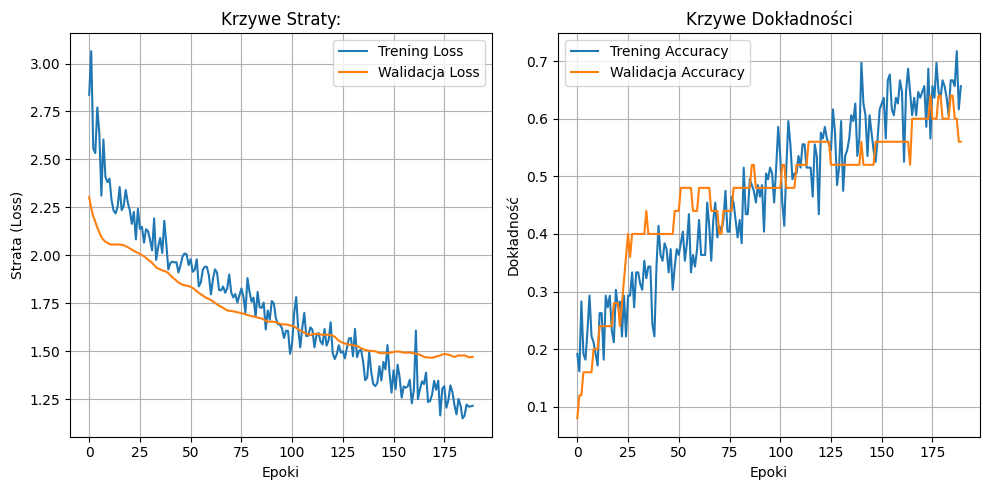

In [208]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history_model_pca.history['loss'], label='Trening Loss')
plt.plot(history_model_pca.history['val_loss'], label='Walidacja Loss')
plt.title('Krzywe Straty:')
plt.xlabel('Epoki')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_model_pca.history['accuracy'], label='Trening Accuracy')
plt.plot(history_model_pca.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Krzywe Dokładności')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


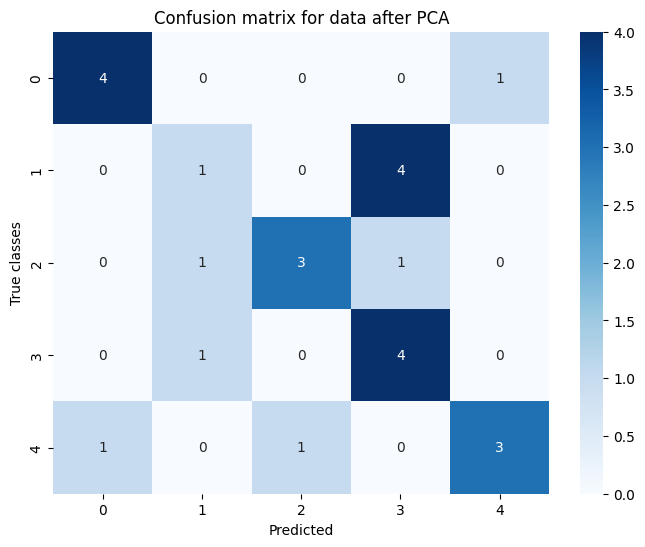

In [209]:
y_pred_probs_pca = model3_copy_pca.predict(X_test_pca_transformed)
y_pred_classes_pca = np.argmax(y_pred_probs_pca, axis=1)
y_true_classes_pca = np.argmax(y_test_pca_arr, axis=1)
cm_pca = confusion_matrix(y_true_classes_pca, y_pred_classes_pca)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3', '4'],
            yticklabels=['0', '1', '2', '3', '4'])
plt.xlabel('Predicted')
plt.ylabel('True classes')
plt.title('Confusion matrix for data after PCA')
plt.show()

Model na danych po redukcji wymiarowosci PCA osiąga niezłe wyniki jednak nie są one w jakilkowiek sposb interpretowalne ponieważ w wyniku działania PCA uzyskujemy 20 principal components które zawirają 95% wariancji oryginalnych danych jednak nie jestesmy w stanie srawdzic które KEGG pathways w jaki konkretny sposób wpływają na predykcje modelu.

In [134]:
tf.keras.backend.clear_session()

In [135]:
model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[35]),
        tf.keras.layers.Dense(64, kernel_regularizer=l2(0.002)), 
        tf.keras.layers.Activation('swish'), 
        tf.keras.layers.Dropout(0.3), 
        tf.keras.layers.Dense(32, kernel_regularizer=l2(0.002)),
        tf.keras.layers.Activation('swish'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(5, activation='softmax')
    ])

In [136]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

early_stopping_cb = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

model.compile(loss='categorical_crossentropy',
                        optimizer=optimizer,
                        metrics=['accuracy'])

history = model.fit(
    X_train_array, y_train_array,
    epochs=300,
    validation_data = (X_test_array, y_test_array),
    callbacks = [early_stopping_cb]
)

Epoch 1/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.1616 - loss: 4.6117 - val_accuracy: 0.2000 - val_loss: 2.2274
Epoch 2/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1717 - loss: 3.5407 - val_accuracy: 0.1600 - val_loss: 2.0136
Epoch 3/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1515 - loss: 3.0324 - val_accuracy: 0.0800 - val_loss: 1.9820
Epoch 4/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2020 - loss: 3.0183 - val_accuracy: 0.2000 - val_loss: 1.9615
Epoch 5/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2323 - loss: 2.7596 - val_accuracy: 0.2000 - val_loss: 1.9459
Epoch 6/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.2424 - loss: 2.3034 - val_accuracy: 0.2800 - val_loss: 1.9298
Epoch 7/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.2121 - loss: 2.5102 - val_accuracy: 0.2400 - val_loss: 1.8995
Epoch 8/300
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1717 - loss: 2.2992 - val_accuracy: 0.3200 - val_loss:

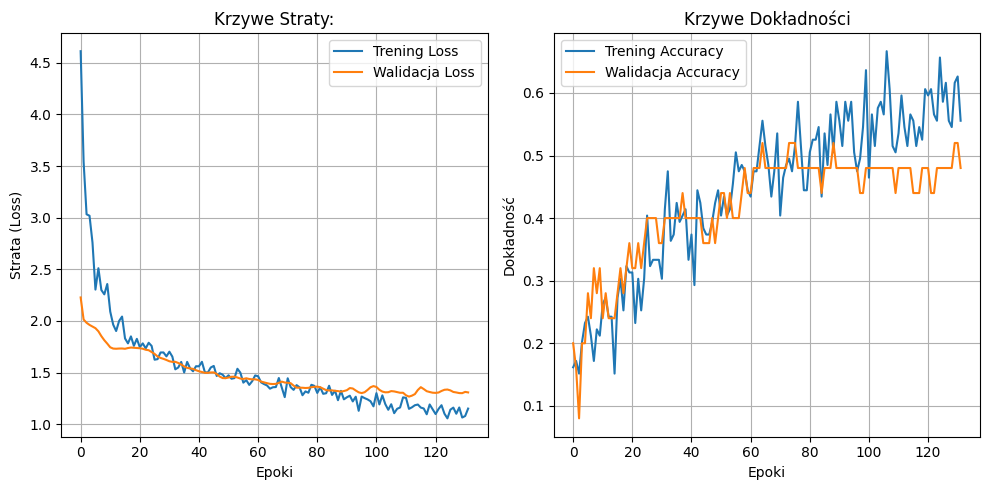

In [137]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Trening Loss')
plt.plot(history.history['val_loss'], label='Walidacja Loss')
plt.title('Krzywe Straty:')
plt.xlabel('Epoki')
plt.ylabel('Strata (Loss)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Trening Accuracy')
plt.plot(history.history['val_accuracy'], label='Walidacja Accuracy')
plt.title('Krzywe Dokładności')
plt.xlabel('Epoki')
plt.ylabel('Dokładność')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [138]:
results = model.evaluate(
    X_test_array,
    y_test_array
)
print(results[0])
print(results[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4800 - loss: 1.2672
1.2672350406646729
0.47999998927116394


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


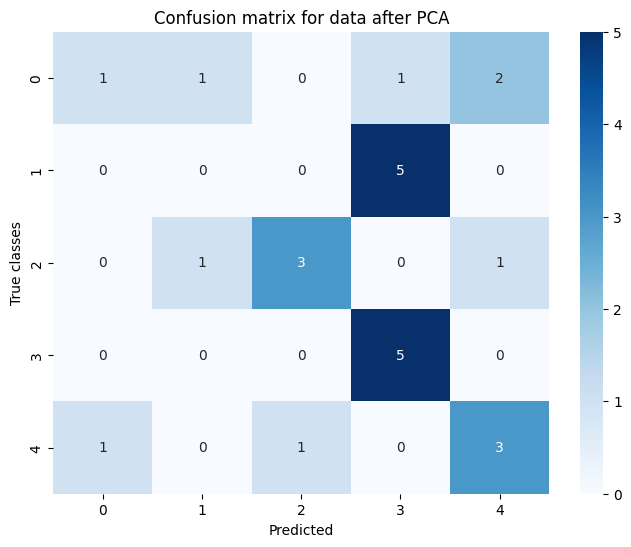

In [139]:
y_pred_probs = model.predict(X_test_array)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_array, axis=1)
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3', '4'],
            yticklabels=['0', '1', '2', '3', '4'])
plt.xlabel('Predicted')
plt.ylabel('True classes')
plt.title('Confusion matrix for data after PCA')
plt.show()